# LIANA: a LIgand-receptor ANalysis frAmework


In [6]:
# use env liana_r

if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

if (!requireNamespace("remotes", quietly = TRUE))
    install.packages("remotes")

if (!requireNamespace("tidyverse", quietly = TRUE))
    install.packages("tidyverse")

if (!requireNamespace("magrittr", quietly = TRUE))
    install.packages("magrittr")

In [9]:
library(tidyverse)
library(magrittr)
library(liana)
library(Seurat)

ERROR: Error: package or namespace load failed for ‘liana’ in loadNamespace(j <- i[[1L]], c(lib.loc, .libPaths()), versionCheck = vI[[j]]):
 there is no package called ‘scran’


In [ ]:
show_resources()

show_methods()

ERROR: Error in show_resources(): could not find function "show_resources"


## Tutorial

In [ ]:
liana_path <- system.file(package = "liana")
testdata <-
  readRDS(file.path(liana_path , "testdata", "input", "testdata.rds"))

testdata %>% dplyr::glimpse()

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay' [package "Seurat"] with 8 slots
  ..@ meta.data   :'data.frame':	90 obs. of  4 variables:
  .. ..$ orig.ident        : Factor w/ 1 level "pbmc3k": 1 1 1 1 1 1 1 1 1 1 ...
  .. ..$ nCount_RNA        : num [1:90] 4903 3914 4973 3281 2641 ...
  .. ..$ nFeature_RNA      : int [1:90] 1352 1112 1445 1015 928 937 899 1713 960 888 ...
  .. ..$ seurat_annotations: Factor w/ 3 levels "B","CD8 T","NK": 1 1 1 1 3 3 1 1 1 1 ...
  ..@ active.assay: chr "RNA"
  ..@ active.ident: Factor w/ 3 levels "B","CD8 T","NK": 1 1 1 1 3 3 1 1 1 1 ...
  .. ..- attr(*, "names")= chr [1:90] "AAACATTGAGCTAC" "AAACTTGAAAAACG" "AAAGGCCTGTCTAG" "AAAGTTTGGGGTGA" ...
  ..@ graphs      : list()
  ..@ neighbors   : list()
  ..@ reductions  : list()
  ..@ images      : list()
  ..@ project.name: chr "SeuratProject"
  ..@ misc        : list()
  ..@ version     :Classes 'package_version', 'numeric_versio

In [ ]:
# Run liana
liana_test <- liana_wrap(testdata)

# Liana returns a list of results, each element of which corresponds to a method
liana_test %>% dplyr::glimpse()

Expression from the `RNA` assay will be used

Running LIANA with `seurat_annotations` as labels!



Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the liana package.
  Please report the issue at <https://github.com/saezlab/liana/issues>.”
Warning message in exec(output, ...):
“3465 genes and/or 0 cells were removed as they had no counts!”
Warning message:
“`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours.”
LIANA: LR summary stats calculated!

Now Running: Natmi

Now Running: Connectome

Now Running: Logfc

Now Running: Sca

Now Running: Cellphonedb

Warning message:
“`progress_estimated()` was deprecated in dplyr 1.0.0.
ℹ The deprecated feature was likely used in the liana package.
  Please report the issue at <https://github.com/saezlab/liana/issues>.”


List of 5
 $ natmi      : tibble [735 × 14] (S3: tbl_df/tbl/data.frame)
  ..$ source          : chr [1:735] "B" "B" "B" "B" ...
  .. ..- attr(*, "levels")= chr [1:3] "B" "CD8 T" "NK"
  ..$ target          : chr [1:735] "B" "B" "B" "B" ...
  .. ..- attr(*, "levels")= chr [1:3] "B" "CD8 T" "NK"
  ..$ ligand.complex  : chr [1:735] "LGALS9" "LGALS9" "LGALS9" "ADAM10" ...
  ..$ ligand          : chr [1:735] "LGALS9" "LGALS9" "LGALS9" "ADAM10" ...
  ..$ receptor.complex: chr [1:735] "PTPRC" "CD44" "CD47" "CD44" ...
  ..$ receptor        : chr [1:735] "PTPRC" "CD44" "CD47" "CD44" ...
  ..$ receptor.prop   : num [1:735] 0.567 0.433 0.5 0.433 0.267 ...
  ..$ ligand.prop     : num [1:735] 0.233 0.233 0.233 0.1 1 ...
  ..$ ligand.expr     : num [1:735] 0.374 0.374 0.374 0.12 2.914 ...
  ..$ receptor.expr   : num [1:735] 0.762 0.655 0.661 0.655 0.499 ...
  ..$ ligand.sum      : num [1:735] 0.535 0.535 0.535 0.363 9.772 ...
  ..$ receptor.sum    : num [1:735] 3.41 2.1 2.1 2.1 3.07 ...
  ..$ prod_we

In [ ]:
# top natmi results
names(liana_test)
unique(liana_test$natmi$source)
unique(liana_test$natmi$target)

natmi_res <- liana_test$natmi

top_natmi <- natmi_res %>%
  arrange(desc(prod_weight)) %>%
  select(
    source,
    target,
    ligand.complex,
    receptor.complex,
    ligand.expr,
    receptor.expr,
    ligand.prop,
    receptor.prop,
    prod_weight,
    edge_specificity
  ) %>%
  head(30)

top_natmi

[1] "natmi"       "connectome"  "logfc"       "sca"         "cellphonedb"

[1] "B"     "NK"    "CD8 T"

[1] "B"     "NK"    "CD8 T"

source,target,ligand.complex,receptor.complex,ligand.expr,receptor.expr,ligand.prop,receptor.prop,prod_weight,edge_specificity
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NK,CD8 T,B2M,CD3D,5.810702,2.190062,1.0,0.9000000,12.725799,0.2512815
CD8 T,CD8 T,B2M,CD3D,5.599934,2.190062,1.0,0.9000000,12.264204,0.2421670
NK,NK,B2M,CD247,5.810702,1.937585,1.0,0.8333333,11.258730,0.2083153
B,CD8 T,B2M,CD3D,5.080301,2.190062,1.0,0.9000000,11.126176,0.2196956
CD8 T,NK,B2M,CD247,5.599934,1.937585,1.0,0.8333333,10.850349,0.2007592
B,NK,B2M,CD247,5.080301,1.937585,1.0,0.8333333,9.843516,0.1821302
NK,CD8 T,HLA-C,CD3D,4.303210,2.190062,1.0,0.9000000,9.424298,0.2619452
CD8 T,CD8 T,HLA-C,CD3D,3.925634,2.190062,1.0,0.9000000,8.597384,0.2389614
NK,CD8 T,HLA-A,CD3D,3.920105,2.190062,1.0,0.9000000,8.585275,0.2548522


In [ ]:
pla_genes <- c(
  "SELP", "SELPLG",   # P-selectin / PSGL-1
  "ITGAM", "ITGB2",   # Mac-1
  "GP1BA", "GP1BB",
  "ITGA2B", "ITGB3",
  "CD40LG", "CD40",
  "CD44", "ICAM1",
  "PECAM1"
)

natmi_res %>%
  filter(
    ligand %in% pla_genes |
      receptor %in% pla_genes |
      ligand.complex %in% pla_genes |
      receptor.complex %in% pla_genes
  ) %>%
  arrange(desc(prod_weight))

ERROR: Error in natmi_res %>% filter(ligand %in% pla_genes | receptor %in% pla_genes | : could not find function "%>%"


In [ ]:
lapply(names(liana_test), function(method) {
  res <- liana_test[[method]]
  message("\n--- ", method, " ---")
  print(head(res))
})


--- natmi ---



# A tibble: 6 × 14
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 7 more variables: ligand.prop <dbl>, ligand.expr <dbl>,
#   receptor.expr <dbl>, ligand.sum <dbl>, receptor.sum <dbl>,
#   prod_weight <dbl>, edge_specificity <dbl>



--- connectome ---



# A tibble: 6 × 11
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 4 more variables: ligand.prop <dbl>, ligand.scaled <dbl>,
#   receptor.scaled <dbl>, weight_sc <dbl>



--- logfc ---



...


--- sca ---



# A tibble: 6 × 12
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 5 more variables: ligand.prop <dbl>, ligand.expr <dbl>,
#   receptor.expr <dbl>, global_mean <dbl>, LRscore <dbl>



--- cellphonedb ---



# A tibble: 6 × 12
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 5 more variables: ligand.prop <dbl>, ligand.expr <dbl>,
#   receptor.expr <dbl>, lr.mean <dbl>, pvalue <dbl>


[[1]]
# A tibble: 6 × 14
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 7 more variables: ligand.prop <dbl>, ligand.expr <dbl>,
#   receptor.expr <dbl>, ligand.sum <dbl>, receptor.sum <dbl>,
#   prod_weight <dbl>, edge_specificity <dbl>

[[2]]
# A tibble: 6 × 11
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 4 more variables: ligand.prop <dbl>, ligand.scaled <dbl>,
#   receptor.scaled <dbl>, weight_sc <dbl>

[[3]]
# A tibble: 6 × 11
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 4 more variables: ligand.prop <dbl>, ligand.log2FC <dbl>,
#   receptor.log2FC <dbl>, logfc_comb <dbl>

[[4]]
# A tibble: 6 × 12
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 5 more variables: ligand.prop <dbl>, ligand.expr <dbl>,
#   receptor.expr <dbl>, global_mean <dbl>, LRscore <dbl>

[[5]]
# A tibble: 6 × 12
  source target ligand.complex ligand receptor.complex receptor receptor.prop
  <chr>  <chr>  <chr>          <chr>  <chr>            <chr>            <dbl>
1 B      B      LGALS9         LGALS9 PTPRC            PTPRC            0.567
2 B      B      LGALS9         LGALS9 CD44             CD44             0.433
3 B      B      LGALS9         LGALS9 CD47             CD47             0.5  
4 B      B      ADAM10         ADAM10 CD44             CD44             0.433
5 B      B      HLA-B          HLA-B  CD3D             CD3D             0.267
6 B      B      HLA-B          HLA-B  CD3G             CD3G             0.167
# ℹ 5 more variables: ligand.prop <dbl>, ligand.expr <dbl>,
#   receptor.expr <dbl>, lr.mean <dbl>, pvalue <dbl>

In [ ]:
tibble(
  method = names(liana_test),
  n_interactions = sapply(liana_test, nrow)
)

method,n_interactions
<chr>,<int>
natmi,735
connectome,735
logfc,735
sca,735
cellphonedb,735


In [ ]:
combined <- bind_rows(
  liana_test,
  .id = "method"
)

combined %>%
  select(method, source, target, ligand.complex, receptor.complex, everything())
  
common_lr <- combined %>%
  count(source, target, ligand.complex, receptor.complex, sort = TRUE)

common_lr %>%
  filter(n >= 3) %>%
  head(30)

method,source,target,ligand.complex,receptor.complex,ligand,receptor,receptor.prop,ligand.prop,ligand.expr,⋯,ligand.scaled,receptor.scaled,weight_sc,ligand.log2FC,receptor.log2FC,logfc_comb,global_mean,LRscore,lr.mean,pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
natmi,B,B,LGALS9,PTPRC,LGALS9,PTPRC,0.5666667,0.2333333,0.3743196,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,LGALS9,CD44,LGALS9,CD44,0.4333333,0.2333333,0.3743196,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,LGALS9,CD47,LGALS9,CD47,0.5000000,0.2333333,0.3743196,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,ADAM10,CD44,ADAM10,CD44,0.4333333,0.1000000,0.1197968,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,HLA-B,CD3D,HLA-B,CD3D,0.2666667,1.0000000,2.9136737,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,HLA-B,CD3G,HLA-B,CD3G,0.1666667,1.0000000,2.9136737,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,HLA-B,CD8B,HLA-B,CD8B,0.1000000,1.0000000,2.9136737,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,ANXA1,FPR1,ANXA1,FPR1,0.1000000,0.2666667,0.3938854,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
natmi,B,B,HLA-A,CD3D,HLA-A,CD3D,0.2666667,1.0000000,3.2691842,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


source,target,ligand.complex,receptor.complex,n
<chr>,<chr>,<chr>,<chr>,<int>
B,B,ADAM10,CD44,5
B,B,ADAM28,ITGA4,5
B,B,ANXA1,FPR1,5
B,B,ARF6,SMAP1,5
B,B,B2M,CD1C,5
B,B,B2M,CD247,5
B,B,B2M,CD3D,5
B,B,B2M,CD3G,5
B,B,BAG6,NCR3,5


In [ ]:
# cellphone db results
cpdb_res <- liana_test$cellphonedb

cpdb_res %>%
  arrange(pvalue) %>%
  head(30)

source,target,ligand.complex,ligand,receptor.complex,receptor,receptor.prop,ligand.prop,ligand.expr,receptor.expr,lr.mean,pvalue
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
B,B,FCER2,FCER2,ITGAM_ITGB2,ITGAM,0.1000000,0.3000000,0.4088867,0.4496973,0.4292920,0
B,B,MIF,MIF,CD44_CD74,CD44,0.4333333,0.6000000,0.9104887,2.5932699,1.7518793,0
B,B,MIF,MIF,CD74_CXCR4,CXCR4,0.6333333,0.6000000,0.9104887,2.9294053,1.9199470,0
B,B,COPA,COPA,CD74,CD74,1.0000000,0.1000000,0.1608555,4.5311493,2.3460024,0
B,B,LTB,LTB,CD40,CD40,0.5000000,0.9333333,2.9626266,0.6859598,1.8242932,0
B,B,CD52,CD52,SIGLEC10,SIGLEC10,0.1666667,1.0000000,2.9258812,0.1908699,1.5583755,0
B,B,LY86,LY86,CD180,CD180,0.2000000,0.5666667,0.9496927,0.3065326,0.6281127,0
B,NK,LGALS9,LGALS9,HAVCR2,HAVCR2,0.2000000,0.2333333,0.3743196,0.3203181,0.3473188,0
B,NK,FCER2,FCER2,ITGAM_ITGB2,ITGAM,0.1666667,0.3000000,0.4088867,1.2206492,0.8147679,0


In [ ]:
# We can aggregate these results into a tibble with consensus ranks
liana_test <- liana_test %>%
  liana_aggregate()

dplyr::glimpse(liana_test)

Now aggregating natmi

Now aggregating connectome

Now aggregating logfc



Now aggregating sca

Now aggregating cellphonedb

Aggregating Ranks



Rows: 735
Columns: 16
$ source                 <chr> "B", "B", "B", "B", "NK", "NK", "B", "B", "CD8 …
$ target                 <chr> "CD8 T", "CD8 T", "CD8 T", "CD8 T", "NK", "B", …
$ ligand.complex         <chr> "HLA-DQA1", "HLA-DQB1", "HLA-DRA", "HLA-DPB1", …
$ receptor.complex       <chr> "LAG3", "LAG3", "LAG3", "LAG3", "ITGB2", "CD1C"…
$ aggregate_rank         <dbl> 1.003283e-06, 4.257720e-05, 4.257720e-05, 6.107…
$ mean_rank              <dbl> 38.3, 46.9, 27.5, 33.7, 28.9, 49.5, 56.9, 35.3,…
$ natmi.edge_specificity <dbl> 0.8945477, 0.8087770, 0.7374111, 0.6235916, 0.5…
$ natmi.rank             <dbl> 2, 5, 7, 12, 20, 66, 1, 11, 75, 8, 10, 28, 100,…
$ connectome.weight_sc   <dbl> 1.0054344, 0.9026001, 1.0097786, 0.9181296, 0.9…
$ connectome.rank        <dbl> 2, 7, 1, 5, 8, 19, 6, 4, 64, 9, 3, 21, 13, 14, …
$ logfc.logfc_comb       <dbl> 2.4495727, 2.2335507, 2.7106868, 2.1918963, 2.2…
$ logfc.rank             <dbl> 2, 4, 1, 6, 3, 52, 8, 5, 82, 9, 7, 61, 23, 25, …
$ sca.LRscore     

### Dotplot

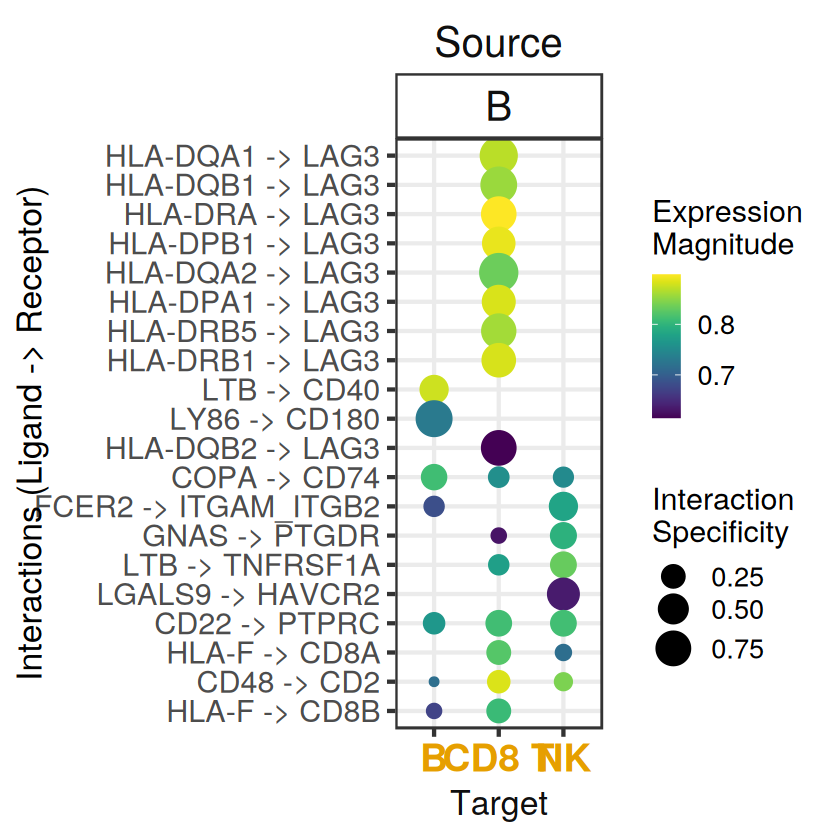

In [ ]:
liana_test %>%
  liana_dotplot(source_groups = c("B"),
                target_groups = c("NK", "CD8 T", "B"),
                ntop = 20)

### Frequency Heatmap

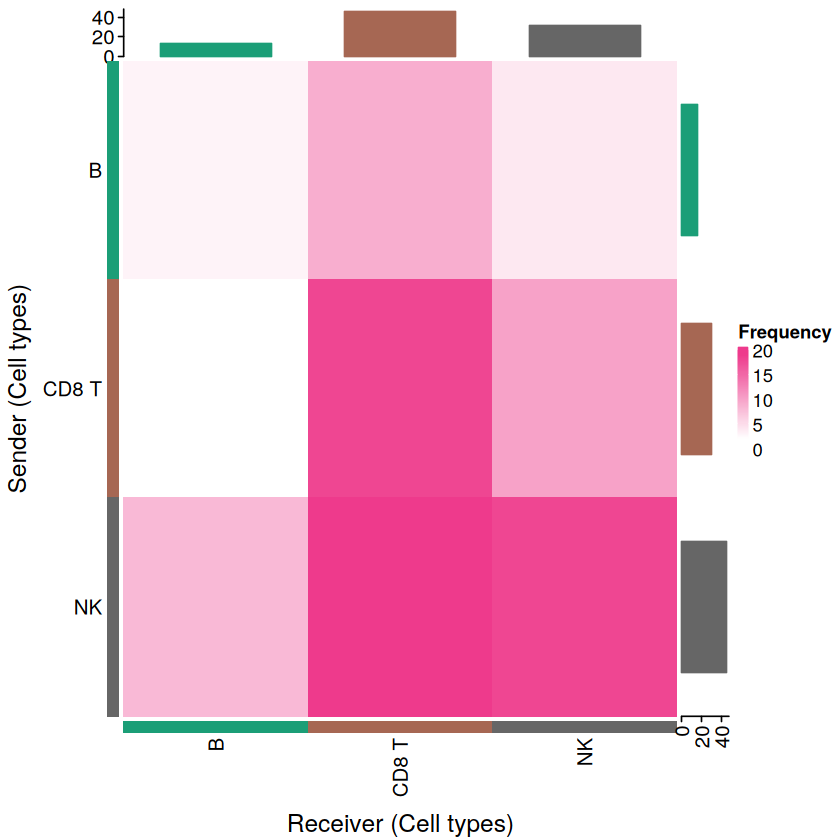

In [ ]:
liana_trunc <- liana_test %>%
   # only keep interactions concordant between methods
  filter(aggregate_rank <= 0.01) # note that these pvals are already corrected

heat_freq(liana_trunc)

### Frequency Chord diagram

In [ ]:
if(!require("circlize")){
  install.packages("circlize", quiet = TRUE,
                   repos = "http://cran.us.r-project.org")
}

Loading required package: circlize

circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




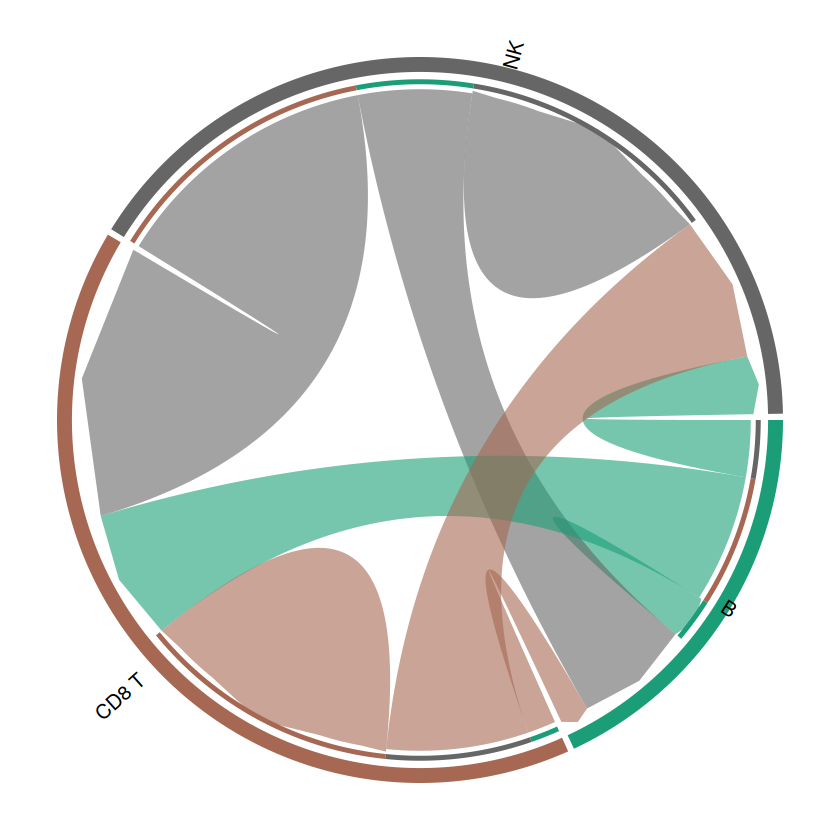

In [ ]:
p <- chord_freq(liana_trunc,
                source_groups = c("CD8 T", "NK", "B"),
                target_groups = c("CD8 T", "NK", "B"))

### Running a method of choice

Running LIANA with `label` as labels!



LIANA: LR summary stats calculated!

Now Running: Cellphonedb



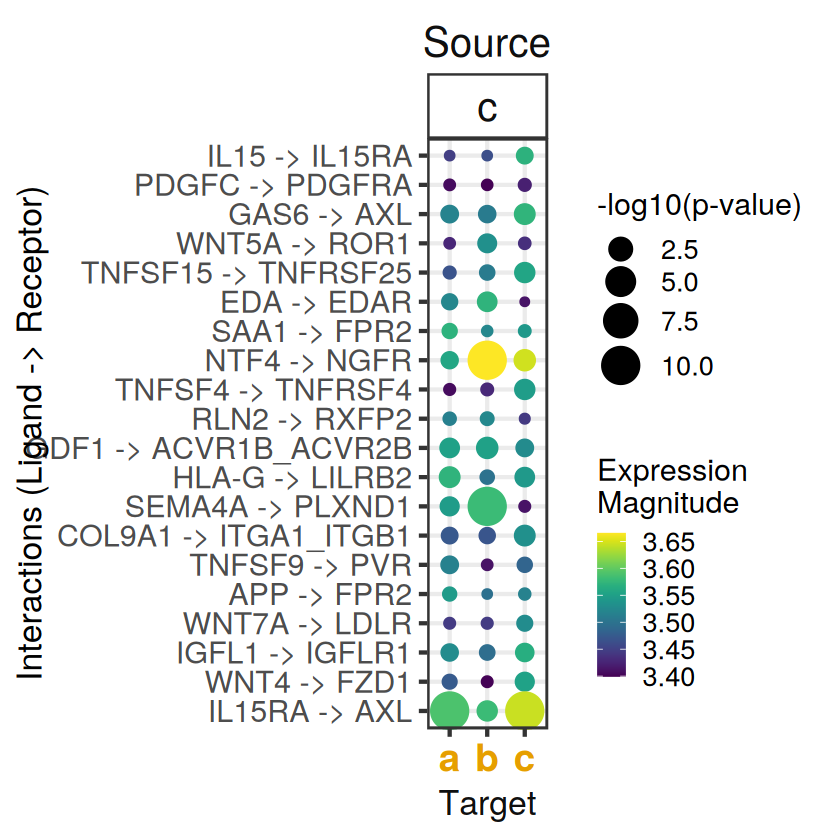

In [ ]:
# Load Sce testdata
sce <- readRDS(file.path(liana_path , "testdata", "input", "testsce.rds"))

# RUN CPDB alone
cpdb_test <- liana_wrap(sce,
                        method = 'cellphonedb',
                        resource = c('CellPhoneDB'),
                        permutation.params = list(nperms=100,
                                                  parallelize=FALSE,
                                                  workers=4),
                        expr_prop=0.05)

# identify interactions of interest
cpdb_int <- cpdb_test %>%
  # only keep interactions with p-val <= 0.05
  filter(pvalue <= 0.05) %>% # this reflects interactions `specificity`
  # then rank according to `magnitude` (lr_mean in this case)
  rank_method(method_name = "cellphonedb",
              mode = "magnitude") %>%
  # keep top 20 interactions (regardless of cell type)
  distinct_at(c("ligand.complex", "receptor.complex")) %>%
  head(20)



# Plot toy results
cpdb_test %>%
  # keep only the interactions of interest
  inner_join(cpdb_int, 
             by = c("ligand.complex", "receptor.complex")) %>%
  # invert size (low p-value/high specificity = larger dot size)
  # + add a small value to avoid Infinity for 0s
  mutate(pvalue = -log10(pvalue + 1e-10)) %>% 
  liana_dotplot(source_groups = c("c"),
                target_groups = c("c", "a", "b"),
                specificity = "pvalue",
                magnitude = "lr.mean",
                show_complex = TRUE,
                size.label = "-log10(p-value)")

In [ ]:
#remotes::install_github("jinworks/CellChat")

promises     (1.3.3    -> 1.5.0     ) [CRAN]
viridisLite  (0.4.2    -> 0.4.3     ) [CRAN]
S7           (NA       -> 0.2.2     ) [CRAN]
isoband      (0.2.7    -> 0.3.0     ) [CRAN]
coda         (NA       -> 0.19-4.1  ) [CRAN]
network      (NA       -> 1.20.0    ) [CRAN]
statnet.c... (NA       -> 4.13.0    ) [CRAN]
ggplot2      (3.5.2    -> 4.0.3     ) [CRAN]
RcppArmad... (15.0.2-1 -> 15.2.7-1  ) [CRAN]
zoo          (1.8-14   -> 1.8-15    ) [CRAN]
urca         (NA       -> 1.3-4     ) [CRAN]
timeDate     (NA       -> 4052.112  ) [CRAN]
fracdiff     (NA       -> 1.5-4     ) [CRAN]
colorspace   (2.1-1    -> 2.1-2     ) [CRAN]
rbibutils    (NA       -> 2.4.1     ) [CRAN]
microbenc... (NA       -> 1.5.0     ) [CRAN]
forecast     (NA       -> 9.0.2     ) [CRAN]
Deriv        (NA       -> 4.2.0     ) [CRAN]
MatrixModels (NA       -> 0.5-4     ) [CRAN]
SparseM      (NA       -> 1.84-2    ) [CRAN]
doBy         (NA       -> 4.7.1     ) [CRAN]
numDeriv     (NA       -> 2016.8-1.1) [CRAN]
reformulas

Skipping 4 packages not available: Biobase, BiocNeighbors, BiocGenerics, ComplexHeatmap

Installing 75 packages: promises, viridisLite, S7, isoband, coda, network, statnet.common, ggplot2, RcppArmadillo, zoo, urca, timeDate, fracdiff, colorspace, rbibutils, microbenchmark, forecast, Deriv, MatrixModels, SparseM, doBy, numDeriv, reformulas, nloptr, minqa, boot, Rdpack, lme4, quantreg, pbkrtest, nnet, Formula, abind, carData, car, corrplot, broom, tidyr, systemfonts, parallelly, listenv, globals, xtable, sourcetools, httpuv, data.table, sna, igraph, ggrepel, rstatix, polynom, ggsignif, ggsci, png, here, GlobalOptions, textshaping, BiocManager, reshape2, gridBase, rngtools, registry, future, collapse, shiny, plotly, ggnetwork, ggpubr, reticulate, circlize, svglite, ggalluvial, NMF, irlba, future.apply

Warning message in i.p(...):
“installation of package ‘Deriv’ had non-zero exit status”
Warning message in i.p(...):
“installation of package ‘numDeriv’ had non-zero exit status”
Warning me

# With our datasets

In [ ]:
data_path <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/"
output_dir <- "../../results/exploration_week1/"

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
file_name <- "gated_ImmuneAging.rds" 

# "immune_aging", "heart", "sepsis", "vaccine", "our_data"
dataset_type <- "immune_aging"